# BRFSS and PLACES Integrated Analysis

## Purpose
This notebook combines the cleaned BRFSS 2023 dataset with the cleaned CDC PLACES state-level dataset to explore whether behavioral risk patterns align with broader public health outcomes across states.

## Main Question
Do behavioral risk patterns in BRFSS align with chronic disease prevalence and related health outcomes in CDC PLACES?

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
BRFSS2023_clean = pd.read_csv("../data/brfss_cleaned.csv")
PLACES_state_cleaned = pd.read_csv("../data/places_state_cleaned.csv")

In [13]:
BRFSS2023_clean.head()

,_state,_drnkdrv,_pneumo3,pneumo_label,drnkdrv_label
0,1,NaN,2.0,No,Missing
1,1,NaN,1.0,Yes,Missing
2,1,2.0,1.0,Yes,Category 2
3,1,2.0,NaN,Missing,Category 2
4,1,NaN,NaN,Missing,Missing


In [14]:
PLACES_state_cleaned.head()

,StateAbbr,Binge drinking among adults,Current cigarette smoking among adults,Diagnosed diabetes among adults,No leisure-time physical activity among adults,Obesity among adults
0,AK,17.837288,19.139286,10.960000,24.465000,35.573684
1,AL,13.949254,17.782308,15.358209,31.533582,41.870400
2,AR,14.590000,18.374667,13.860403,35.146000,40.967606
3,AZ,15.383333,14.355172,12.190000,25.060000,33.263333
4,CA,16.685217,12.511818,11.148246,24.531034,30.129630


In [15]:
print("BRFSS cleaned shape:", BRFSS2023_clean.shape)
print("PLACES state cleaned shape:", PLACES_state_cleaned.shape)

BRFSS cleaned shape: (465, 5)
PLACES state cleaned shape: (50, 6)


## Preparing BRFSS for State-Level Comparison

The cleaned PLACES dataset is already at the state level, but the BRFSS dataset still needs to be summarized in a comparable way. To do this, the original BRFSS data will be reloaded, cleaned for the selected variables, and grouped by state.

This step is necessary because the project question focuses on whether behavioral patterns align with broader health outcomes across states.

In [16]:
# Reload data
BRFSS2023_raw = pd.read_csv(r"C:\Users\alin2\Downloads\BRFSS2023.csv")

In [17]:
#Select only the needed columns

BRFSS_subset = BRFSS2023_raw[['_state', '_drnkdrv', '_pneumo3']].copy()
BRFSS_subset.head()

,_state,_drnkdrv,_pneumo3
0,1,9,2.0
1,1,9,1.0
2,1,9,1.0
3,1,9,1.0
4,1,2,1.0


In [18]:
# Convert to numeric
BRFSS_subset['_state'] = pd.to_numeric(BRFSS_subset['_state'], errors='coerce')
BRFSS_subset['_drnkdrv'] = pd.to_numeric(BRFSS_subset['_drnkdrv'], errors='coerce')
BRFSS_subset['_pneumo3'] = pd.to_numeric(BRFSS_subset['_pneumo3'], errors='coerce')

In [19]:
#Clean special codes
BRFSS_subset['_drnkdrv'] = BRFSS_subset['_drnkdrv'].replace([7, 9, 77, 99], np.nan)
BRFSS_subset['_pneumo3'] = BRFSS_subset['_pneumo3'].replace([7, 9], np.nan)

In [20]:
#Create a state abbreviation mapping

state_map = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE',
    11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA',
    26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV',
    33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND', 39: 'OH',
    40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD', 47: 'TN',
    48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}

In [21]:
# Add state abbreviation column
BRFSS_subset['StateAbbr'] = BRFSS_subset['_state'].map(state_map)
BRFSS_subset.head()

,_state,_drnkdrv,_pneumo3,StateAbbr
0,1,NaN,2.0,AL
1,1,NaN,1.0,AL
2,1,NaN,1.0,AL
3,1,NaN,1.0,AL
4,1,2.0,1.0,AL


In [22]:
#Create a simple state-level BRFSS summary

BRFSS_state = BRFSS_subset.groupby('StateAbbr').agg(
    drnkdrv_cat2_pct=('_drnkdrv', lambda x: (x == 2).mean() * 100),
    pneumo_yes_pct=('_pneumo3', lambda x: (x == 1).mean() * 100)
).reset_index()

BRFSS_state.head()

,StateAbbr,drnkdrv_cat2_pct,pneumo_yes_pct
0,AK,49.628959,20.235294
1,AL,38.743696,26.501605
2,AR,36.254906,28.686227
3,AZ,46.709870,29.519774
4,CA,46.025384,21.217435


In [23]:
#Check the shape
BRFSS_state.shape

(49, 3)

### Interpretation

The BRFSS dataset has now been summarized to the state level, making it more comparable to the cleaned PLACES dataset. Each row represents one state, and the summary columns show selected behavioral and preventive health response patterns.

This transformation is important because it moves the BRFSS data from individual-level records to a state-level structure that can be merged with broader public health outcomes from CDC PLACES.

In [27]:
set(PLACES_state_cleaned['StateAbbr']) - set(BRFSS_state['StateAbbr'])

{'US'}

## Removing the National Summary Row

The PLACES state-level dataset includes one extra row labeled `US`, which represents a national summary rather than an individual state. Since the goal of this project is to compare state-level patterns, that row is removed before merging the datasets.

In [28]:
PLACES_state_cleaned = PLACES_state_cleaned[PLACES_state_cleaned['StateAbbr'] != 'US'].copy()
PLACES_state_cleaned.shape

(49, 6)

## Merging BRFSS and PLACES

Now that both datasets are organized at the state level, they can be merged using the shared `StateAbbr` column. This creates one integrated dataset that combines behavioral response patterns from BRFSS with broader health outcome indicators from CDC PLACES.

In [29]:
merged_df = pd.merge(BRFSS_state, PLACES_state_cleaned, on='StateAbbr', how='inner')
merged_df.head()

,StateAbbr,drnkdrv_cat2_pct,pneumo_yes_pct,Binge drinking among adults,Current cigarette smoking among adults,Diagnosed diabetes among adults,No leisure-time physical activity among adults,Obesity among adults
0,AK,49.628959,20.235294,17.837288,19.139286,10.960000,24.465000,35.573684
1,AL,38.743696,26.501605,13.949254,17.782308,15.358209,31.533582,41.870400
2,AR,36.254906,28.686227,14.590000,18.374667,13.860403,35.146000,40.967606
3,AZ,46.709870,29.519774,15.383333,14.355172,12.190000,25.060000,33.263333
4,CA,46.025384,21.217435,16.685217,12.511818,11.148246,24.531034,30.129630


In [30]:
merged_df.shape

(49, 8)

## Merged Dataset Interpretation

The merged dataset combines behavioral indicators from BRFSS with chronic disease and health outcome measures from CDC PLACES at the state level.

Each row represents a U.S. state, and the dataset now includes both:
- Behavioral risk patterns (e.g., drinking-related behavior, preventive responses)
- Health outcomes (e.g., obesity, diabetes, physical inactivity)

This integrated dataset enables direct comparison between lifestyle behaviors and health outcomes, which is central to the project’s problem statement.

## Exploring Relationship: Behavior vs Obesity

To begin answering the problem statement, we explore whether behavioral patterns are associated with obesity prevalence.

Specifically, we examine whether states with higher levels of certain behaviors also show higher obesity rates.

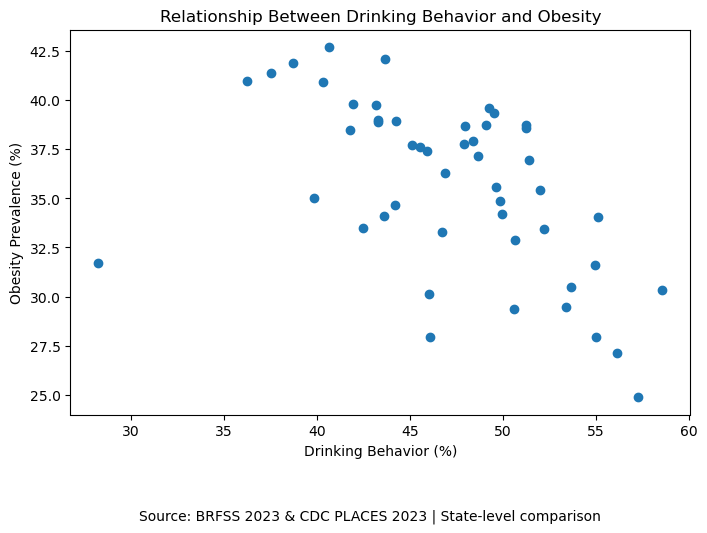

In [31]:
#Relationship between behavior & obesity

plt.figure(figsize=(8,5))

plt.scatter(
    merged_df['drnkdrv_cat2_pct'],
    merged_df['Obesity among adults']
)

plt.title('Relationship Between Drinking Behavior and Obesity')
plt.xlabel('Drinking Behavior (%)')
plt.ylabel('Obesity Prevalence (%)')

plt.figtext(0.5, -0.1,
            "Source: BRFSS 2023 & CDC PLACES 2023 | State-level comparison",
            ha='center')

plt.show()

### Interpretation: Drinking Behavior vs Obesity

The scatter plot shows a weak and inconsistent relationship between drinking-related behavior and obesity prevalence across states.

There is no clear upward or downward trend, suggesting that higher levels of this drinking behavior do not strongly correspond to higher or lower obesity rates.

Some states with higher drinking percentages actually have lower obesity, while others show the opposite pattern. This indicates that drinking behavior alone may not be a strong predictor of obesity at the state level.

Overall, this suggests that obesity is likely influenced by multiple factors, and not just a single behavioral indicator.

## Exploring Relationship: Physical Inactivity vs Obesity

Physical inactivity is a well-known risk factor for chronic diseases. In this step, we examine whether states with higher levels of inactivity also show higher obesity prevalence.

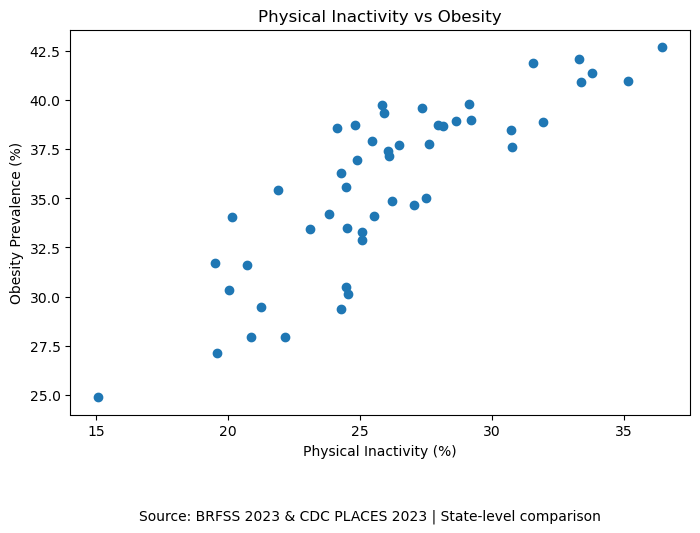

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(
    merged_df['No leisure-time physical activity among adults'],
    merged_df['Obesity among adults']
)

plt.title('Physical Inactivity vs Obesity')
plt.xlabel('Physical Inactivity (%)')
plt.ylabel('Obesity Prevalence (%)')

plt.figtext(0.5, -0.1,
            "Source: BRFSS 2023 & CDC PLACES 2023 | State-level comparison",
            ha='center')

plt.show()

### Interpretation: Physical Inactivity vs Obesity

The scatter plot shows a clear positive relationship between physical inactivity and obesity prevalence across states.

States with higher levels of physical inactivity tend to have higher obesity rates. The data points follow an upward trend, indicating a strong association between these two variables.

Compared to the previous analysis, this relationship is much more consistent, suggesting that physical inactivity is a more significant behavioral factor influencing obesity.

This finding supports existing public health research, which identifies lack of physical activity as a key contributor to obesity and related chronic diseases.

## Comparing Behavioral Patterns in High-Obesity States

To better understand behavioral differences, we examine the top 5 states with the highest obesity rates and compare their associated behavioral indicators.

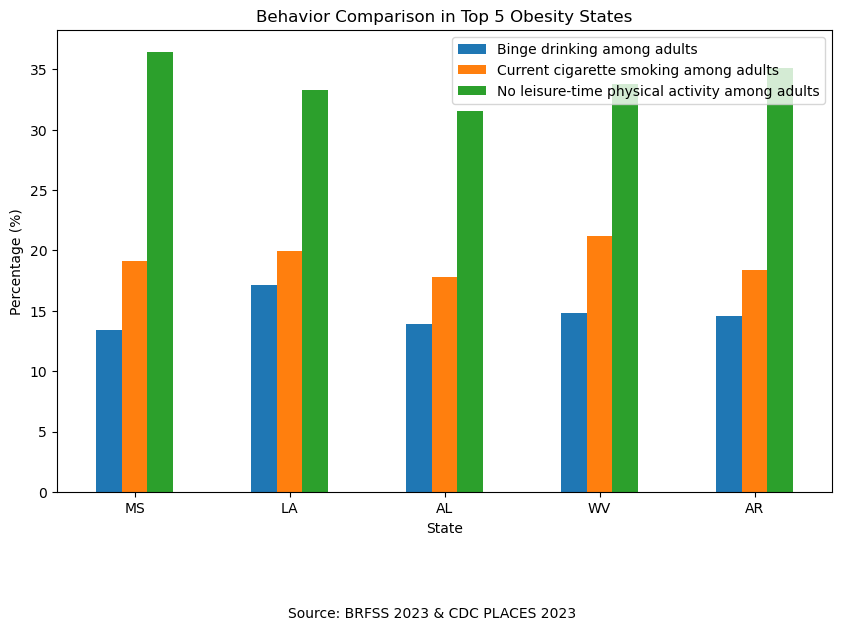

In [33]:
# Get top 5 states by obesity
top_states = merged_df.sort_values(by='Obesity among adults', ascending=False).head(5)

# Set index
top_states = top_states.set_index('StateAbbr')

# Select variables to compare
top_states[['Binge drinking among adults',
            'Current cigarette smoking among adults',
            'No leisure-time physical activity among adults']].plot(kind='bar', figsize=(10,6))

plt.title('Behavior Comparison in Top 5 Obesity States')
plt.xlabel('State')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=0)

plt.figtext(0.5, -0.1,
            "Source: BRFSS 2023 & CDC PLACES 2023",
            ha='center')

plt.show()

### Interpretation: Behavioral Patterns in High-Obesity States

The bar chart compares key behavioral indicators across the top five states with the highest obesity prevalence.

A clear pattern emerges: all five states show consistently high levels of physical inactivity, which stands out as the dominant behavioral factor. In contrast, binge drinking and smoking levels are relatively lower and more stable across these states.

This suggests that physical inactivity plays a more critical role in obesity compared to other behaviors analyzed. The consistency of this pattern across multiple states strengthens the evidence that lack of physical activity is a major contributing factor to higher obesity rates.

## Final Conclusion

This project examined whether behavioral risk patterns from BRFSS align with chronic disease outcomes reported in CDC PLACES data.

The analysis revealed that not all behaviors have a strong relationship with health outcomes. For example, drinking-related behavior showed little to no clear association with obesity.

However, physical inactivity demonstrated a strong and consistent positive relationship with obesity across states. States with higher inactivity levels tended to have significantly higher obesity prevalence.

Additionally, comparisons among high-obesity states showed that physical inactivity was the most prominent and consistent behavioral factor, while other behaviors such as smoking and drinking varied less.

Overall, the findings suggest that certain lifestyle behaviors, particularly physical inactivity, play a critical role in shaping population-level health outcomes, while others may have weaker or more complex relationships.